In [21]:
import os, glob, json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = '/Users/alt2005/plasma_research/plasma_coil_optimization/PF_location_optimization/examples/comparisons/combined_boundary_DIIID/convergence_w5_bayesian/good/04_26'
PAT = re.compile(r'alpha:([\d.]+),weight:([\deE+-.]+),lambda:([\deE+-.]+),coils:(\d+)')
METHOD = 'Bayesian'

In [22]:
rows = []
trajectories = {}
for case_dir in sorted(glob.glob(os.path.join(ROOT, 'alpha:*'))):
    m = PAT.search(os.path.basename(case_dir))
    if not m:
        continue
    alpha, weight, lam, coils = float(m.group(1)), float(m.group(2)), float(m.group(3)), int(m.group(4))
    for run_dir in sorted(glob.glob(os.path.join(case_dir, 'run_*'))):
        rj = os.path.join(run_dir, 'results.json')
        if not os.path.exists(rj):
            continue
        d = json.load(open(rj))
        if METHOD not in d.get('methods', {}):
            continue
        r = d['methods'][METHOD]
        run_id = os.path.basename(run_dir)
        rows.append({
            'alpha': alpha, 'weight_fb': weight, 'lambda': lam, 'coils': coils,
            'run': run_id,
            'best_cost': r.get('best_cost'),
            'best_flux_err': r.get('best_flux_err'),
            'best_fb_cost': r.get('best_fb_cost'),
            'n_evals': r.get('n_evals'),
            'time_s': r.get('time'),
            'fb_failures': r.get('fb_failures'),
            'pts_refined': r.get('pts_refined'),
            'n_acq_unique': r.get('n_acq_unique'),
            'time_bayesian_phase': r.get('time_bayesian_phase'),
            'random_state': r.get('random_state'),
        })
        trajectories[(weight, coils, run_id)] = {
            'cost': np.asarray(r.get('cost_history', []), dtype=float),
            'times': np.asarray(r.get('times', []), dtype=float),
            'flux': np.asarray(r.get('flux_err_history', []), dtype=float),
            'fb': np.asarray(r.get('fb_cost_history', []), dtype=float),
            'conv': np.asarray(r.get('convergence_history', []), dtype=float),
        }
df = pd.DataFrame(rows).sort_values(['weight_fb', 'coils', 'run']).reset_index(drop=True)
print('cases loaded:', len(df))
df

cases loaded: 17


,alpha,weight_fb,lambda,coils,run,best_cost,best_flux_err,best_fb_cost,n_evals,time_s,fb_failures,pts_refined,n_acq_unique,time_bayesian_phase,random_state
0,0.75,0.0001,0.000001,2,run_01,0.193787,0.017590,0.002301,696,28164.166390,195,3,3,4911.984167,1
1,0.75,0.0001,0.000001,3,run_01,0.769141,0.010269,0.000287,560,24990.092636,26,3,3,5294.119621,1
2,0.75,0.0001,0.000001,4,run_01,0.327069,0.006613,0.000074,648,27570.708628,21,3,3,5423.732715,1
3,0.75,0.0001,0.000001,6,run_01,0.130254,0.002931,0.000021,618,32719.523979,67,3,3,9534.307125,1
4,0.75,0.0010,0.000001,2,run_01,0.297572,0.015175,0.004681,551,23951.035992,9,3,3,4019.848091,1
5,0.75,0.0010,0.000001,3,run_01,0.903849,0.008387,0.000371,514,26162.654520,107,3,3,5248.815438,1
6,0.75,0.0010,0.000001,4,run_01,0.327408,0.006613,0.000074,612,29224.322629,94,3,3,6282.088037,1
7,0.75,0.0010,0.000001,5,run_01,0.048745,0.003659,0.000018,712,36344.770947,170,3,3,7951.969983,1
8,0.75,0.0100,0.000001,2,run_01,0.200630,0.017825,0.002415,495,21216.845395,7,3,3,5230.632039,1
9,0.75,0.0100,0.000001,3,run_01,0.811881,0.015905,0.000258,493,20605.617875,10,3,3,4282.569346,1


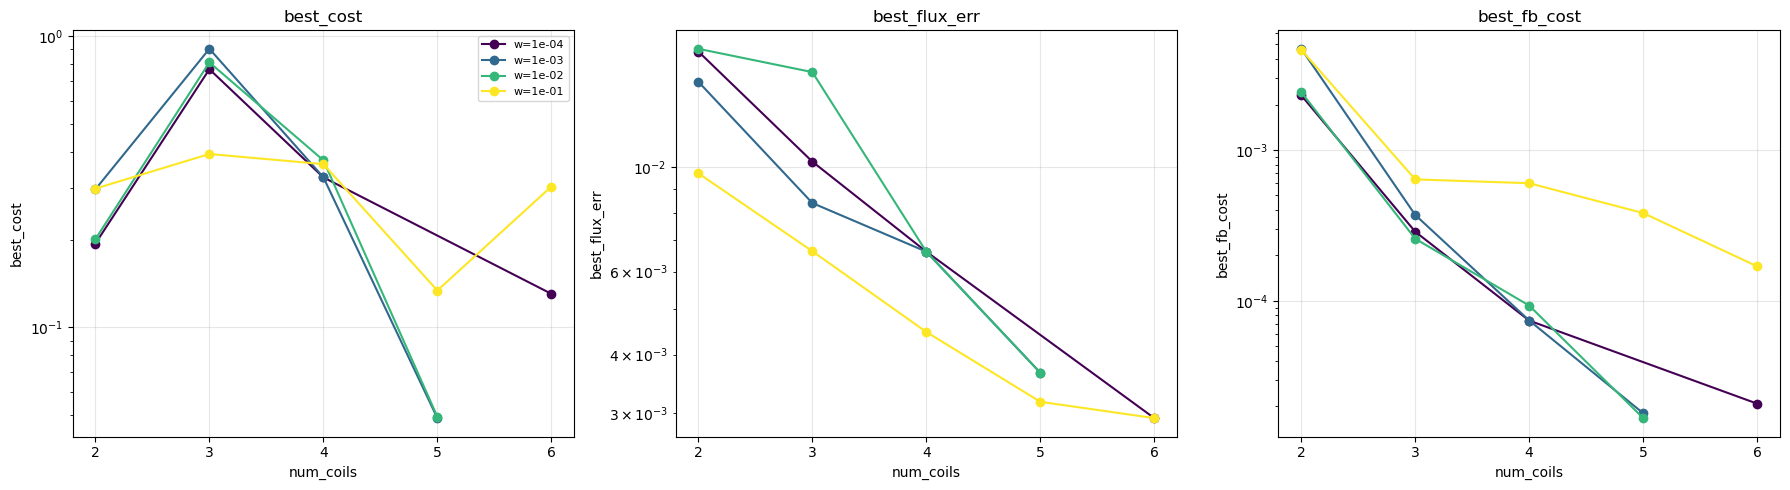

In [23]:
weights = sorted(df['weight_fb'].unique())
coils_all = sorted(df['coils'].unique())
cmap = plt.get_cmap('viridis', len(weights))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, metric in enumerate(['best_cost', 'best_flux_err', 'best_fb_cost']):
    ax = axes[i]
    for j, w in enumerate(weights):
        sub = df[df['weight_fb'] == w].groupby('coils')[metric].mean().reset_index()
        ax.plot(sub['coils'], sub[metric], marker='o', color=cmap(j), label=f'w={w:.0e}')
    ax.set_xlabel('num_coils')
    ax.set_ylabel(metric)
    ax.set_yscale('log')
    ax.set_xticks(np.arange(2, 7, 1))
    ax.set_title(metric)
    ax.grid(True, alpha=0.3)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


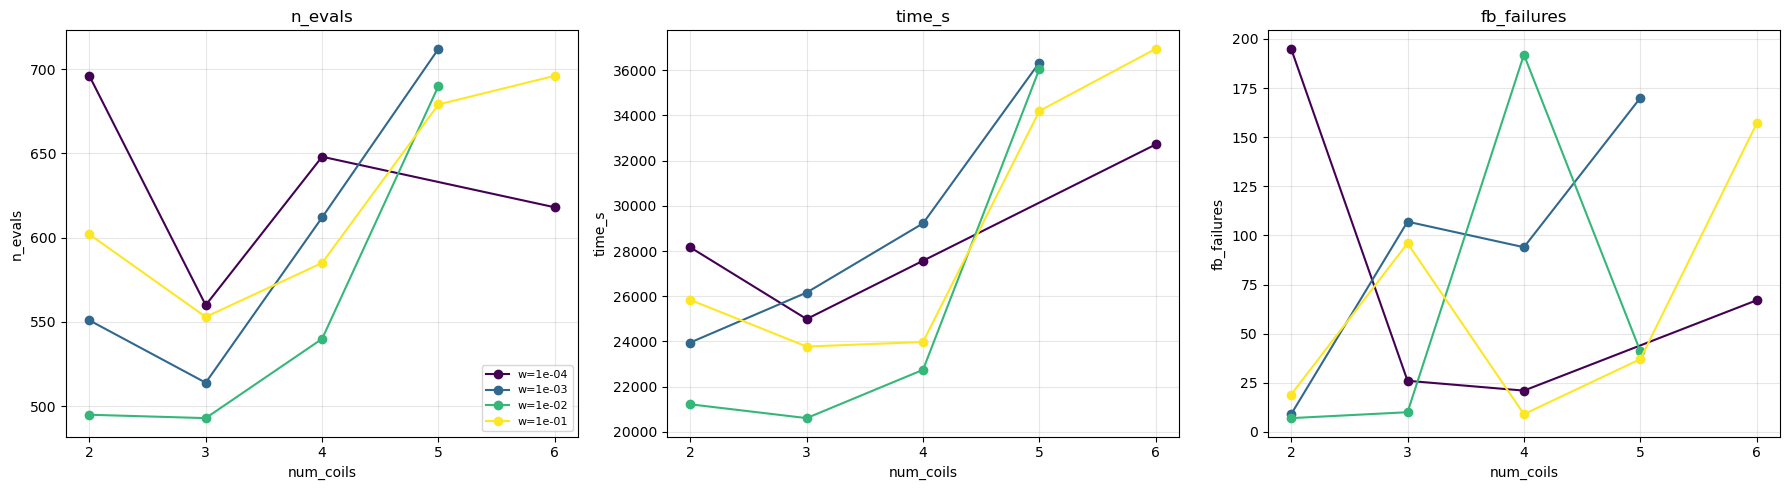

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, metric in enumerate(['n_evals', 'time_s', 'fb_failures']):
    ax = axes[i]
    for j, w in enumerate(weights):
        sub = df[df['weight_fb'] == w].groupby('coils')[metric].mean().reset_index()
        ax.plot(sub['coils'], sub[metric], marker='o', color=cmap(j), label=f'w={w:.0e}')
    ax.set_xlabel('num_coils')
    ax.set_ylabel(metric)
    ax.set_xticks(np.arange(2, 7, 1))
    ax.set_title(metric)
    ax.grid(True, alpha=0.3)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

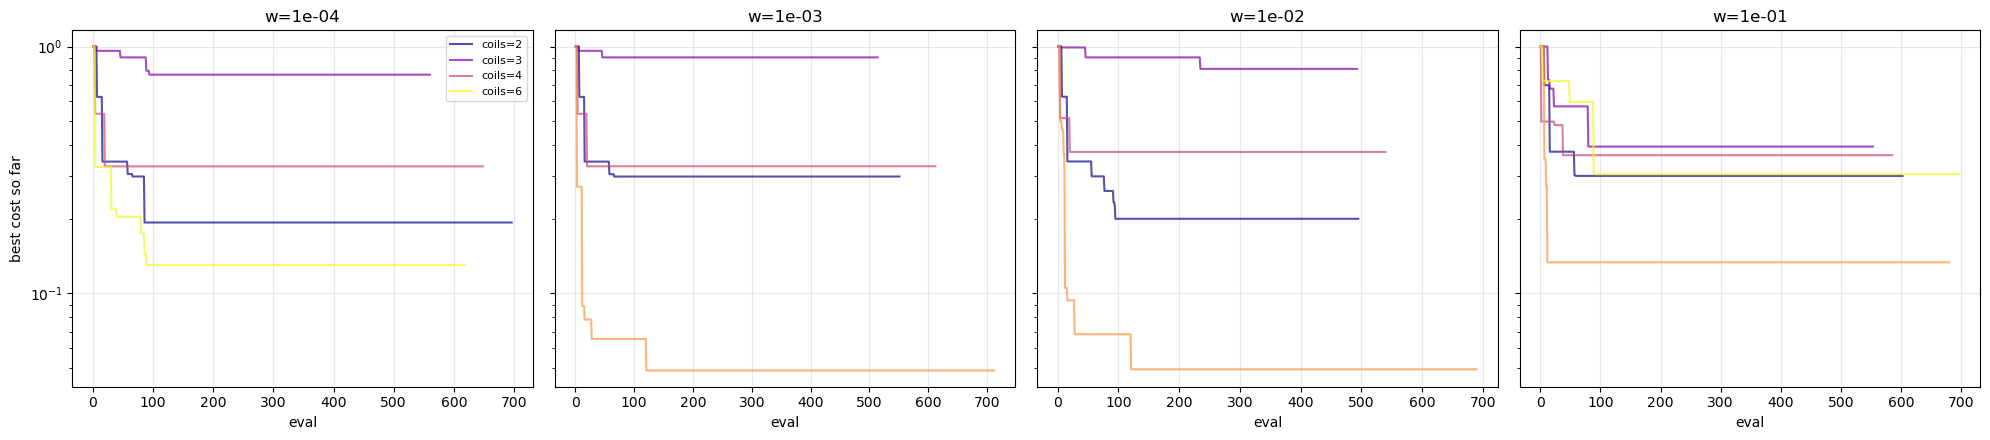

In [25]:
fig, axes = plt.subplots(1, len(weights), figsize=(5 * len(weights), 4.5), sharey=True)
if len(weights) == 1:
    axes = [axes]
ccmap = plt.get_cmap('plasma', len(coils_all))
for j, w in enumerate(weights):
    ax = axes[j]
    for k, nc in enumerate(coils_all):
        for (ww, cc, rid), traj in trajectories.items():
            if ww != w or cc != nc:
                continue
            y = traj['cost']
            if len(y) == 0:
                continue
            ax.plot(np.arange(1, len(y) + 1), np.minimum.accumulate(y), color=ccmap(k), alpha=0.7, label=f'coils={nc}' if rid == 'run_01' else None)
    ax.set_xlabel('eval')
    ax.set_yscale('log')
    ax.set_title(f'w={w:.0e}')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('best cost so far')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

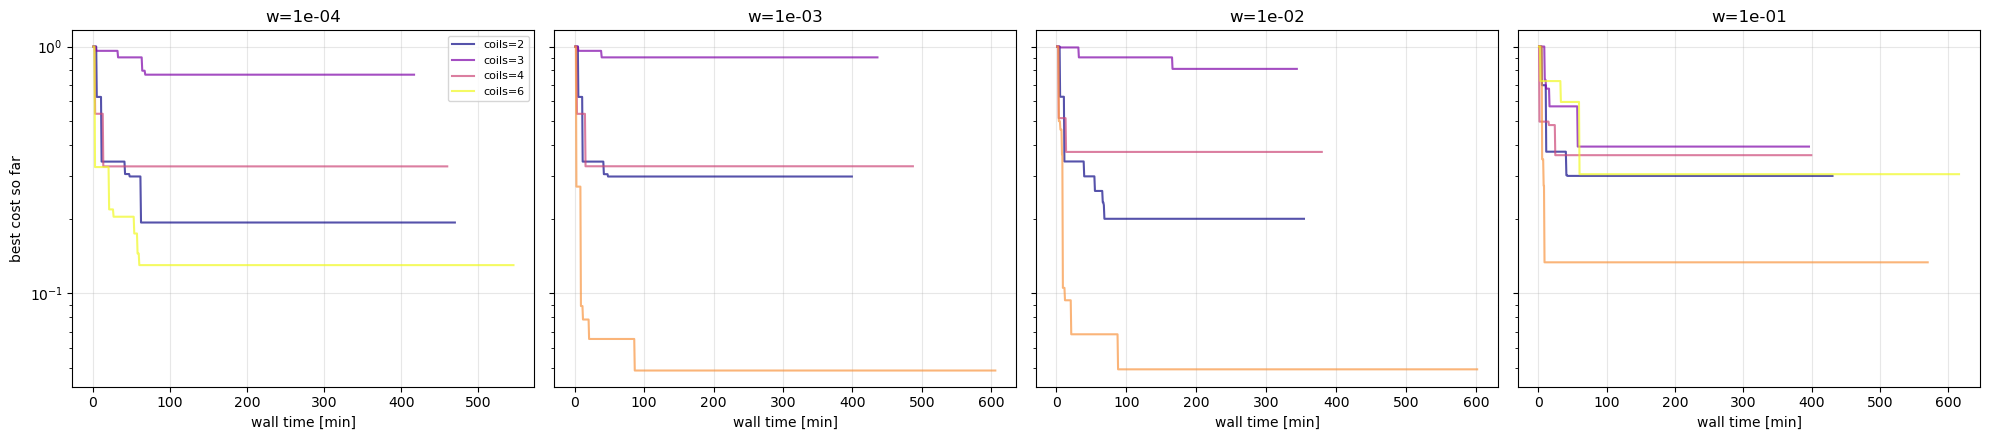

In [26]:
fig, axes = plt.subplots(1, len(weights), figsize=(5 * len(weights), 4.5), sharey=True)
if len(weights) == 1:
    axes = [axes]
for j, w in enumerate(weights):
    ax = axes[j]
    for k, nc in enumerate(coils_all):
        for (ww, cc, rid), traj in trajectories.items():
            if ww != w or cc != nc:
                continue
            t = traj['times']
            y = traj['cost']
            if len(y) == 0 or len(t) == 0:
                continue
            ax.plot(t / 60.0, np.minimum.accumulate(y), color=ccmap(k), alpha=0.7, label=f'coils={nc}' if rid == 'run_01' else None)
    ax.set_xlabel('wall time [min]')
    ax.set_yscale('log')
    ax.set_title(f'w={w:.0e}')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('best cost so far')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

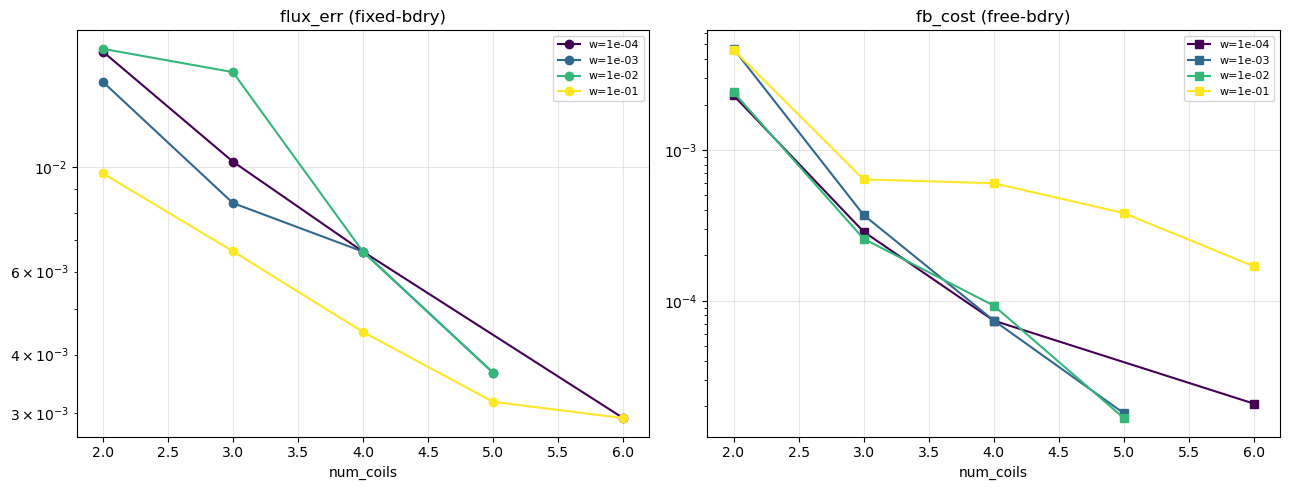

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for j, w in enumerate(weights):
    sub_flux = df[df['weight_fb'] == w].groupby('coils')['best_flux_err'].mean().reset_index()
    sub_fb = df[df['weight_fb'] == w].groupby('coils')['best_fb_cost'].mean().reset_index()
    axes[0].plot(sub_flux['coils'], sub_flux['best_flux_err'], marker='o', color=cmap(j), label=f'w={w:.0e}')
    axes[1].plot(sub_fb['coils'], sub_fb['best_fb_cost'], marker='s', color=cmap(j), label=f'w={w:.0e}')
for ax, t in zip(axes, ['flux_err (fixed-bdry)', 'fb_cost (free-bdry)']):
    ax.set_xlabel('num_coils')
    ax.set_yscale('log')
    ax.set_title(t)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [28]:
pivot_cost = df.groupby(['weight_fb', 'coils'])['best_cost'].mean().unstack('coils')
pivot_flux = df.groupby(['weight_fb', 'coils'])['best_flux_err'].mean().unstack('coils')
pivot_fb = df.groupby(['weight_fb', 'coils'])['best_fb_cost'].mean().unstack('coils')
print('best_cost')
print(pivot_cost)
print('best_flux_err')
print(pivot_flux)
print('best_fb_cost')
print(pivot_fb)

best_cost
coils             2         3         4         5         6
weight_fb                                                  
0.0001     0.193787  0.769141  0.327069       NaN  0.130254
0.0010     0.297572  0.903849  0.327408  0.048745       NaN
0.0100     0.200630  0.811881  0.374291  0.049289       NaN
0.1000     0.299281  0.393382  0.363093  0.133693  0.304135
best_flux_err
coils             2         3         4         5         6
weight_fb                                                  
0.0001     0.017590  0.010269  0.006613       NaN  0.002931
0.0010     0.015175  0.008387  0.006613  0.003659       NaN
0.0100     0.017825  0.015905  0.006613  0.003659       NaN
0.1000     0.009700  0.006627  0.004466  0.003175  0.002931
best_fb_cost
coils             2         3         4         5         6
weight_fb                                                  
0.0001     0.002301  0.000287  0.000074       NaN  0.000021
0.0010     0.004681  0.000371  0.000074  0.000018       NaN
0.0